In [1]:
###########################################################################################################################################################
############################ This notebook estimates best hyperparameters for Random Forest models ########################################################
###########################################################################################################################################################

In [2]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error, make_scorer

In [3]:
# Import the raw data directory
pathToFile = 'E:/Amibatec/Updated2026/TA_SpeciesClustersPts_GEEformated_Covariables_Sampled.csv'
rawData = pd.read_csv(pathToFile,sep=",")
Data = pd.DataFrame(rawData)
print('Number of points in the dataset : ',Data.shape[0])
Data.columns

Number of points in the dataset :  1074


Index(['system:index', 'aet', 'bio01', 'bio02', 'bio03', 'bio04', 'bio05',
       'bio06', 'bio07', 'bio08', 'bio09', 'bio10', 'bio11', 'bio12', 'bio13',
       'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'biomes', 'bulk',
       'clay', 'cluster1per', 'cluster2per', 'cluster3per', 'def_',
       'ecoregions', 'evi', 'gHM', 'gpp', 'height', 'lai', 'lat', 'latitude',
       'lon', 'longitude', 'ndvi', 'nontreeCover', 'nonvegetated', 'npp',
       'pdsi', 'pet', 'ph', 'pop', 'pr', 'sand', 'snowCover', 'soc', 'soil',
       'tmmn', 'tmmx', 'treeCover', 'vap', 'vpd', 'vs', 'water', '.geo'],
      dtype='object')

In [4]:
# Rename columns
Data.rename(columns={
             'cluster1per':'Species cluster 1',
             'cluster2per':'Species cluster 2',
             'cluster3per':'Species cluster 3',
             'bio01': 'Annual Mean Temperature',
             'bio02':'Mean Diurnal Range',
             'bio03':'Isothermality',
             'bio04':'Temperature Seasonality',
             'bio05':'Max Temperature of Warmest Month',
             'bio06':'Min Temperature of Coldest Month',
             'bio07':'Temperature Annual Range',
             'bio08':'Mean Temperature of Wettest Quarter',
             'bio09':'Mean Temperature of Driest Quarter',
             'bio10':'Mean Temperature of Warmest Quarter',
             'bio11':'Mean Temperature of Coldest Quarter',
             'bio12':'Annual Precipitation',
             'bio13':'Precipitation of Wettest Month',
             'bio14':'Precipitation of Driest Month',
             'bio15':'Precipitation Seasonality',
             'bio16':'Precipitation of Wettest Quarter',
             'bio17':'Precipitation of Driest Quarter',
             'bio18':'Precipitation of Warmest Quarter',
             'bio19':'Precipitation of Coldest Quarter',
             'aet': 'Evapotranspiration',
             'def_': 'Climate water deficit',
             'pdsi': 'Palmer Drought Severity Index',
             'pet': 'Reference evapotranspiration',
             'pr': 'Precipitation accumulation',
             'soil': 'Soil moisture',
             'tmmn': 'Minimum temperature',
             'tmmx': 'Maximum temperature',
             'vap': 'Vapor pressure',
             'vpd': 'Vapor pressure deficit',
             'vs': 'Wind-speed at 10m',
             'snowCover': 'Snow cover',
             'bulk':'Soil bulk density at 0-30 cm depth',
             'clay':'Clay content at 0-30 cm depth',
             'soc':'Soil organic carbon content at 0-30 cm depth',
             'ph':'Soil pH in H2O at 0-30 cm depth',
             'sand':'Sand content',
             'water':'Soil water content',
             'treeCover': 'Percent tree cover',
             'nontreeCover': 'Percent non tree cover',
             'nonvegetated': 'Percent non vegetation',
             'ndvi':'Normalized Difference Vegetation Index',
             'evi':'Enhanced Vegetation Index',
             'gpp':'Gross primary production',
             'npp':'Net photosynthesis',
             'lai':'leaf area index',
             'biomes':'Potential distribution of biomes',
             'ecoregions':'Ecoregions',
             'height':'Elevation',
             'pop':'The estimated number of persons per square kilometer',
             'gHM': 'Global Human Modification'}, inplace=True)

# Rename biome names
BiomeNames = {1:'tropical evergreen broadleaf forest',
              2:'tropical semi-evergreen broadleaf forest',
              3:'tropical deciduous broadleaf forest and woodland',
              4:'warm-temperate evergreen broadleaf and mixed forest',
              7:'cool-temperate rainforest',
              8:'cool evergreen needleleaf forest',
              9:'cool mixed forest',
              13:'temperate deciduous broadleaf forest',
              14:'cold deciduous forest',
              15:'cold evergreen needleleaf forest',
              16:'temperate sclerophyll woodland and shrubland',
              17:'temperate evergreen needleleaf open woodland',
              18:'tropical savanna',
              20:'xerophytic woods/scrub',
              22:'steppe',
              27:'desert',
              28:'graminoid and forb tundra',
              30:'erect dwarf shrub tundra',
              31:'low and high shrub tundra',
              32:'prostrate dwarf shrub tundra'}

Data['Potential distribution of biomes'] = Data['Potential distribution of biomes'].replace(BiomeNames)

In [5]:
# Arrange the data for stratification
BiomesPivot = Data.pivot(index='system:index',columns='Potential distribution of biomes',values='Species cluster 1')
BiomeCount = BiomesPivot.count()
BiomeCount

Potential distribution of biomes
cold evergreen needleleaf forest                       159
cool evergreen needleleaf forest                         6
cool mixed forest                                      375
cool-temperate rainforest                               37
erect dwarf shrub tundra                                15
graminoid and forb tundra                                1
low and high shrub tundra                                9
steppe                                                  14
temperate deciduous broadleaf forest                   144
temperate evergreen needleleaf open woodland            15
temperate sclerophyll woodland and shrubland            23
tropical deciduous broadleaf forest and woodland        14
tropical evergreen broadleaf forest                     78
tropical savanna                                        16
tropical semi-evergreen broadleaf forest                 3
warm-temperate evergreen broadleaf and mixed forest    151
xerophytic woods/scrub 

In [6]:
# Delete data with only 1 data per strata
#indexNames = Data[Data['Potential distribution of biomes'] == 'graminoid and forb tundra'].index
#Data.drop(indexNames, inplace=True)
#indexNames = Data[Data['Potential distribution of biomes'] == 'desert'].index
#Data.drop(indexNames, inplace=True)
#indexNames = Data[Data['Potential distribution of biomes'] == 'cold deciduous forest'].index
#Data.drop(indexNames, inplace=True)

In [7]:
# load the variable to predict
y = Data['Species cluster 2']

# load variables for prediction
X = Data.drop(['Species cluster 1','Species cluster 2','Species cluster 3','Ecoregions','Potential distribution of biomes'], axis=1)

# Variable used for stratification
#Xstrat = Data['Potential distribution of biomes']

In [8]:
# Create an empty dataframe to store RF best parameters
best_parameters = pd.DataFrame(index=range(10),columns=range(4))
best_parameters.columns = ['RF_runs_num','n_estimators','max_features','min_samples_leaf']

# Create an empty dataframe to store RF model scores
scores = pd.DataFrame(index=range(10),columns=range(5))
scores.columns = ['RF_runs_num', 'R2_train', 'RMSE_train', 'R2_test', 'RMSE_test']

# Create an empty dataframe to store feature importance
importance = pd.DataFrame(index=range(10),columns=range(51))
importance.columns = ['RF_runs_num', 'Annual Mean Temperature',
             'Mean Diurnal Range',
             'Isothermality',
             'Temperature Seasonality',
             'Max Temperature of Warmest Month',
             'Min Temperature of Coldest Month',
             'Temperature Annual Range',
             'Mean Temperature of Wettest Quarter',
             'Mean Temperature of Driest Quarter',
             'Mean Temperature of Warmest Quarter',
             'Mean Temperature of Coldest Quarter',
             'Annual Precipitation',
             'Precipitation of Wettest Month',
             'Precipitation of Driest Month',
             'Precipitation Seasonality',
             'Precipitation of Wettest Quarter',
             'Precipitation of Driest Quarter',
             'Precipitation of Warmest Quarter',
             'Precipitation of Coldest Quarter',
             'Evapotranspiration',
             'Climate water deficit',
             'Palmer Drought Severity Index',
             'Reference evapotranspiration',
             'Precipitation accumulation',
             'Soil moisture',
             'Minimum temperature',
             'Maximum temperature',
             'Vapor pressure',
             'Vapor pressure deficit',
             'Wind-speed at 10m',
             'Snow cover',
             'Soil bulk density at 0-30 cm depth',
             'Clay content at 0-30 cm depth',
             'Soil organic carbon content at 0-30 cm depth',
             'Soil pH in H2O at 0-30 cm depth',
             'Sand content',
             'Soil water content',
             'Percent tree cover',
             'Percent non tree cover',
             'Percent non vegetation',
             'Normalized Difference Vegetation Index',
             'Enhanced Vegetation Index',
             'Gross primary production',
             'Net photosynthesis',
             'leaf area index',
             'Elevation',
             'latitude',
             'longitude',
             'The estimated number of persons per square kilometer',
             'Global Human Modification']

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


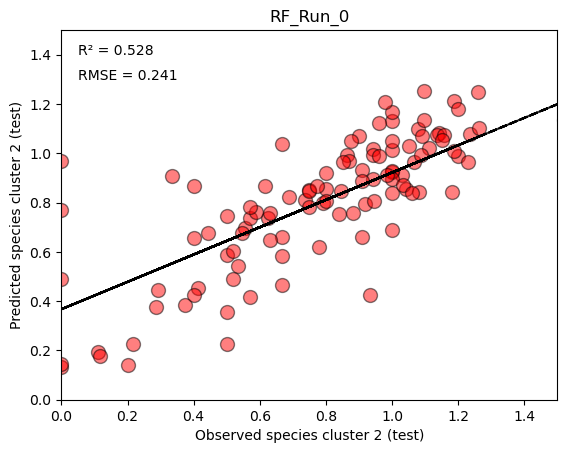

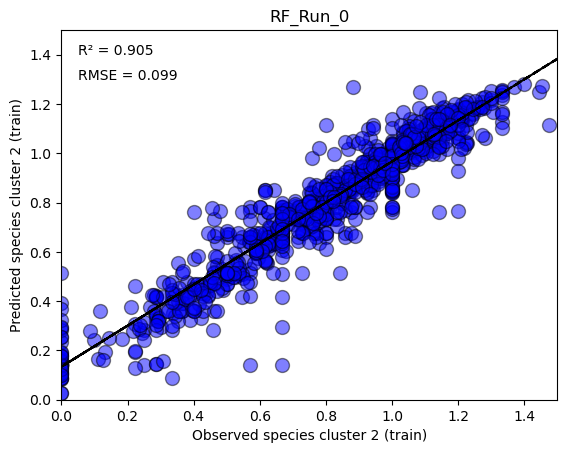

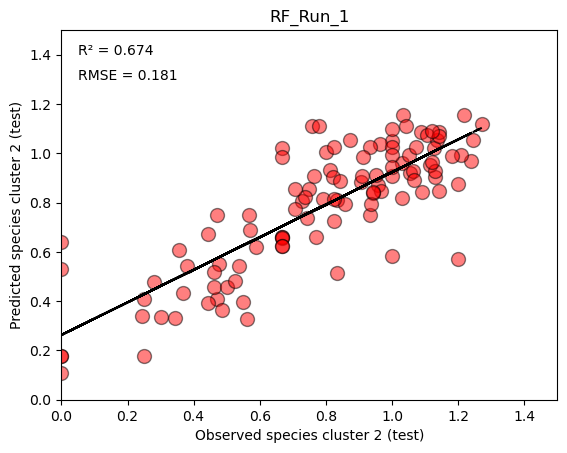

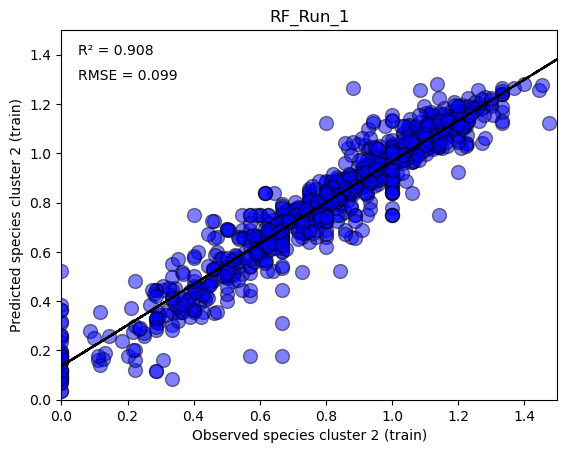

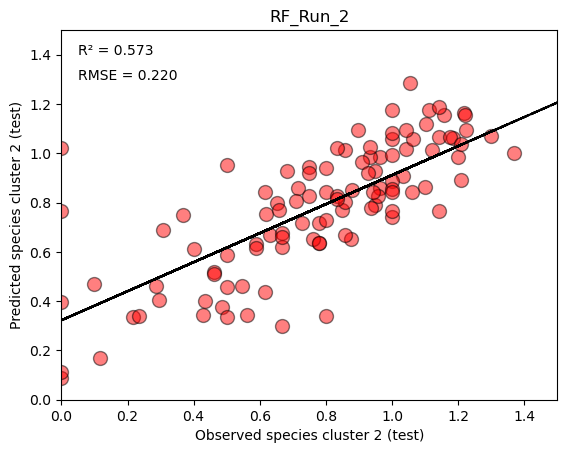

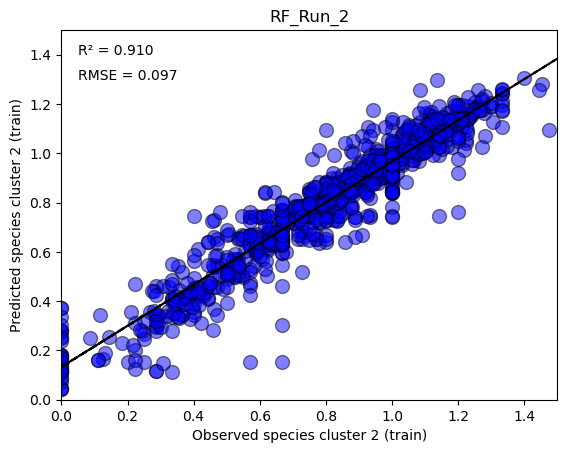

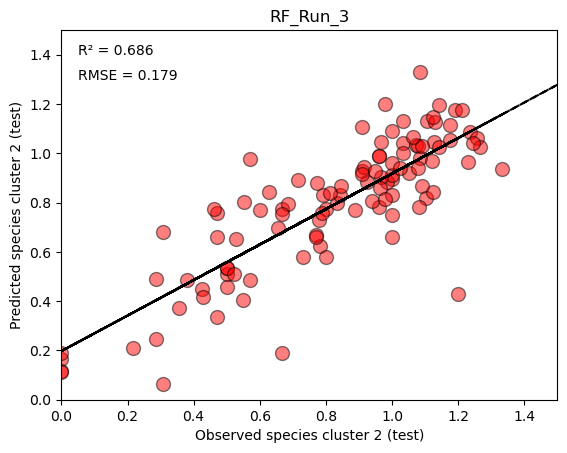

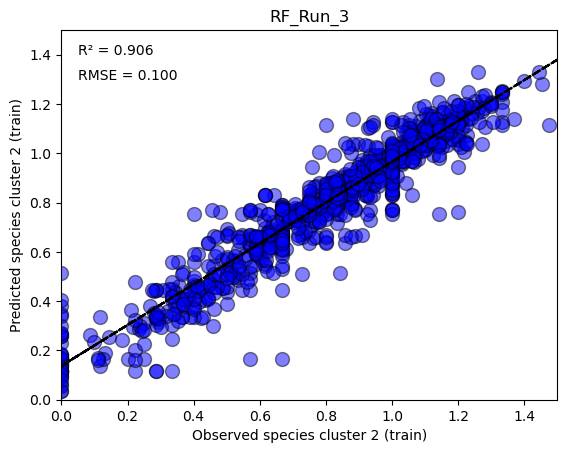

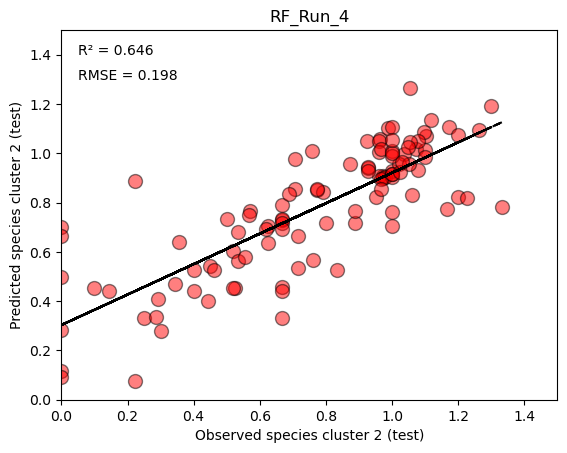

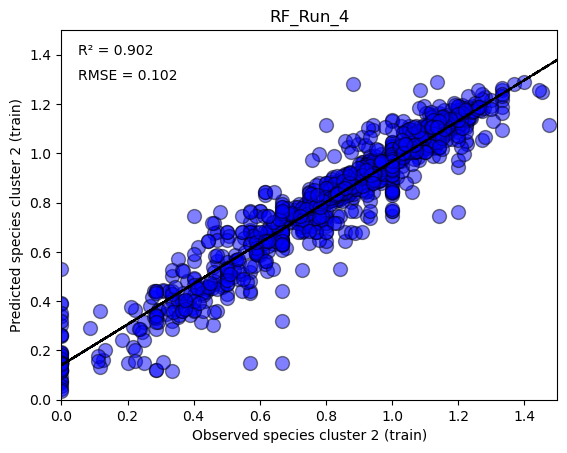

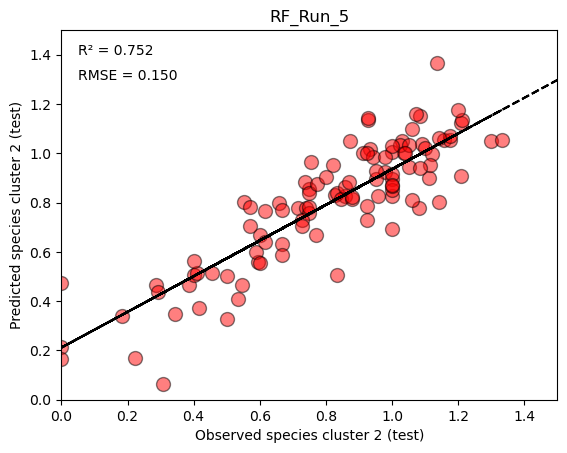

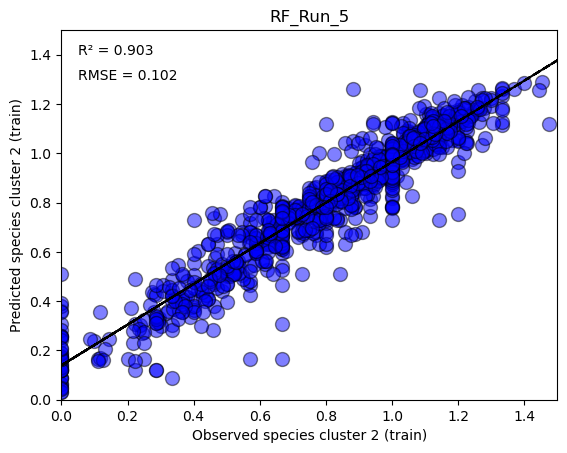

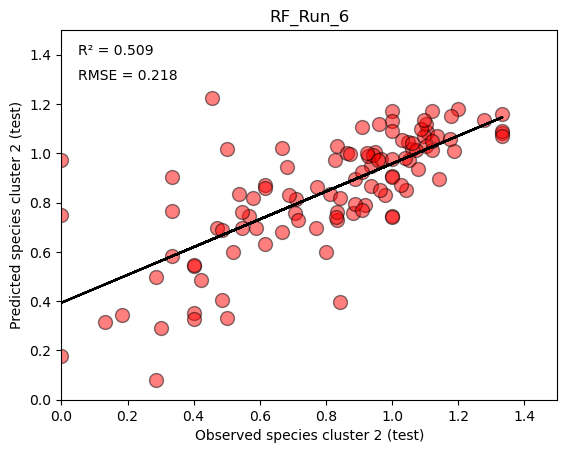

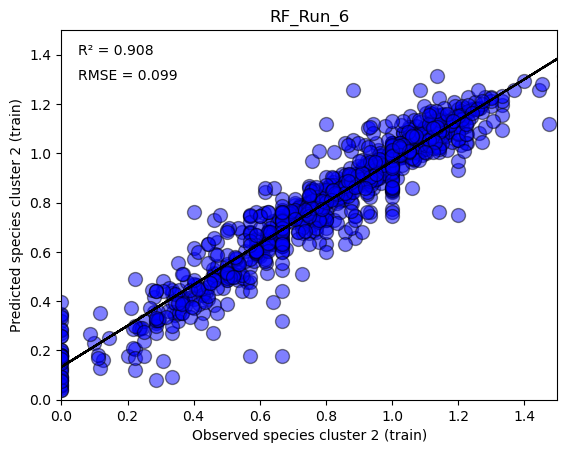

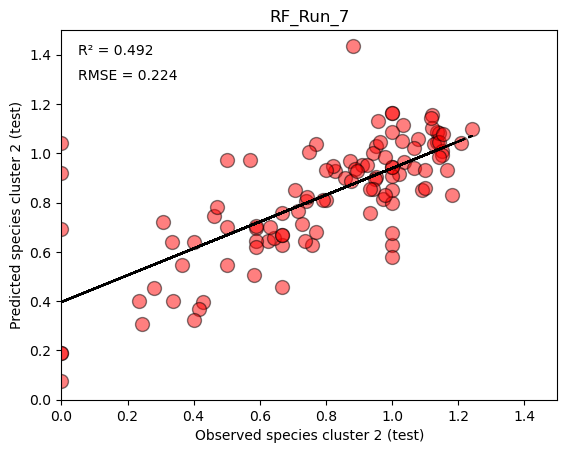

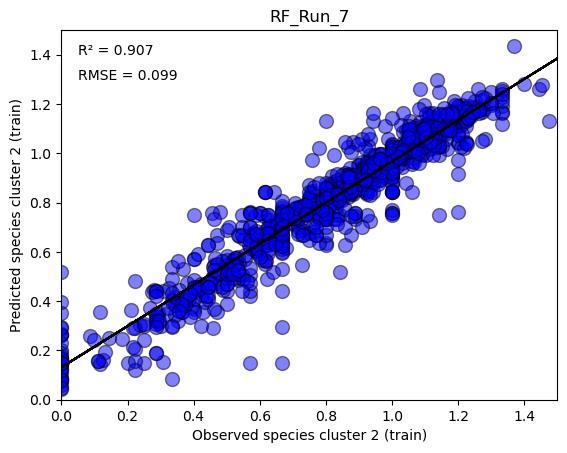

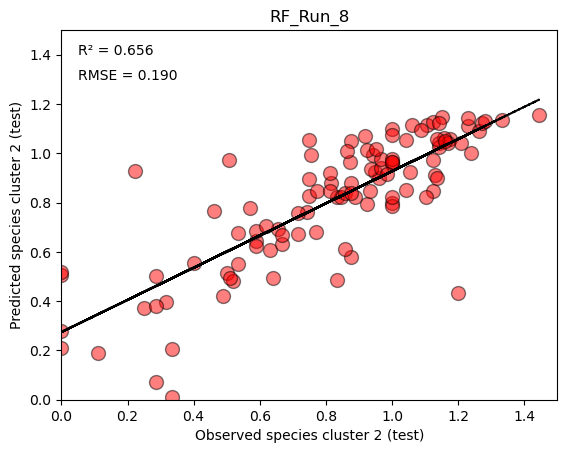

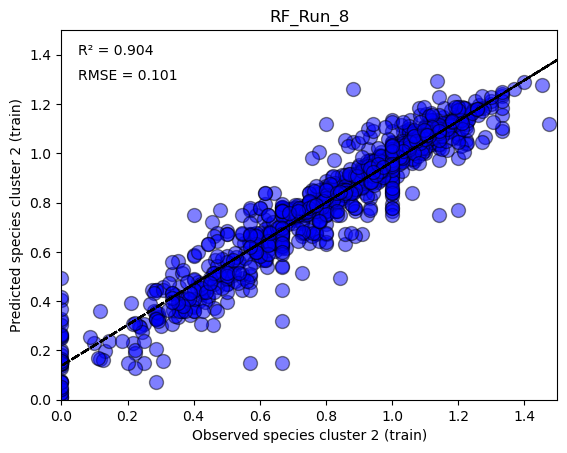

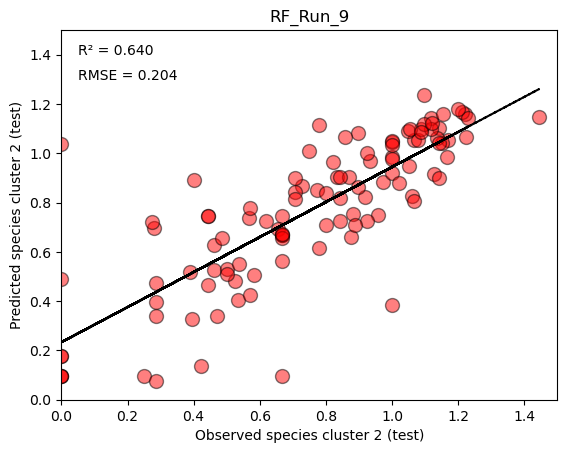

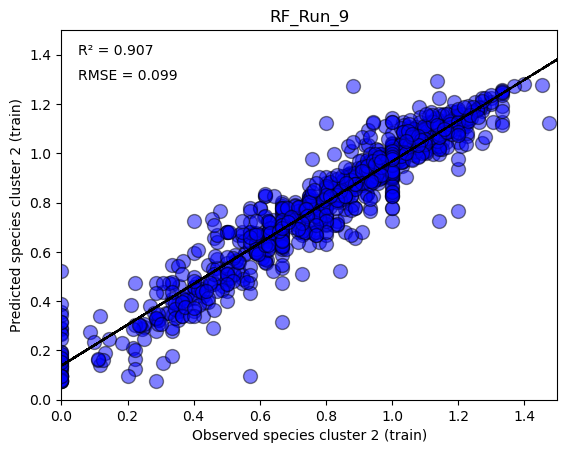

In [9]:
# Produce an ensemble of random forest models
for i in range(10):
    # Split the dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=i, stratify= None)
    
    # Save coordinates for test
    Test_lat = X_test['latitude']
    Test_lon = X_test['longitude']
    
    # Save coordinates for train
    Train_lat = X_train['latitude']
    Train_lon = X_train['longitude']
    
    # Filter train and test variables for prediction based on the feature selection step
    X_train = X_train[['Annual Mean Temperature',
             'Mean Diurnal Range',
             'Isothermality',
             'Temperature Seasonality',
             'Max Temperature of Warmest Month',
             'Min Temperature of Coldest Month',
             'Temperature Annual Range',
             'Mean Temperature of Wettest Quarter',
             'Mean Temperature of Driest Quarter',
             'Mean Temperature of Warmest Quarter',
             'Mean Temperature of Coldest Quarter',
             'Annual Precipitation',
             'Precipitation of Wettest Month',
             'Precipitation of Driest Month',
             'Precipitation Seasonality',
             'Precipitation of Wettest Quarter',
             'Precipitation of Driest Quarter',
             'Precipitation of Warmest Quarter',
             'Precipitation of Coldest Quarter',
             'Evapotranspiration',
             'Climate water deficit',
             'Palmer Drought Severity Index',
             'Reference evapotranspiration',
             'Precipitation accumulation',
             'Soil moisture',
             'Minimum temperature',
             'Maximum temperature',
             'Vapor pressure',
             'Vapor pressure deficit',
             'Wind-speed at 10m',
             'Snow cover',
             'Soil bulk density at 0-30 cm depth',
             'Clay content at 0-30 cm depth',
             'Soil organic carbon content at 0-30 cm depth',
             'Soil pH in H2O at 0-30 cm depth',
             'Sand content',
             'Soil water content',
             'Percent tree cover',
             'Percent non tree cover',
             'Percent non vegetation',
             'Normalized Difference Vegetation Index',
             'Enhanced Vegetation Index',
             'Gross primary production',
             'Net photosynthesis',
             'leaf area index',
             'Elevation',
             'latitude',
             'longitude',
             'The estimated number of persons per square kilometer',
             'Global Human Modification'
                      ]]
    
    X_test = X_test[['Annual Mean Temperature',
             'Mean Diurnal Range',
             'Isothermality',
             'Temperature Seasonality',
             'Max Temperature of Warmest Month',
             'Min Temperature of Coldest Month',
             'Temperature Annual Range',
             'Mean Temperature of Wettest Quarter',
             'Mean Temperature of Driest Quarter',
             'Mean Temperature of Warmest Quarter',
             'Mean Temperature of Coldest Quarter',
             'Annual Precipitation',
             'Precipitation of Wettest Month',
             'Precipitation of Driest Month',
             'Precipitation Seasonality',
             'Precipitation of Wettest Quarter',
             'Precipitation of Driest Quarter',
             'Precipitation of Warmest Quarter',
             'Precipitation of Coldest Quarter',
             'Evapotranspiration',
             'Climate water deficit',
             'Palmer Drought Severity Index',
             'Reference evapotranspiration',
             'Precipitation accumulation',
             'Soil moisture',
             'Minimum temperature',
             'Maximum temperature',
             'Vapor pressure',
             'Vapor pressure deficit',
             'Wind-speed at 10m',
             'Snow cover',
             'Soil bulk density at 0-30 cm depth',
             'Clay content at 0-30 cm depth',
             'Soil organic carbon content at 0-30 cm depth',
             'Soil pH in H2O at 0-30 cm depth',
             'Sand content',
             'Soil water content',
             'Percent tree cover',
             'Percent non tree cover',
             'Percent non vegetation',
             'Normalized Difference Vegetation Index',
             'Enhanced Vegetation Index',
             'Gross primary production',
             'Net photosynthesis',
             'leaf area index',
             'Elevation',
             'latitude',
             'longitude',
             'The estimated number of persons per square kilometer',
             'Global Human Modification'
                    ]]

    # Make a grid of hyperparameters to tune
    n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1000, num = 10)] # Number of trees in random forest (numberOfTrees)
    max_features = [int(x) for x in np.linspace(start = 1, stop = 9, num = 9)] # The number of features to consider when looking for the best split (variablesPerSplit)
    min_samples_leaf = [int(x) for x in np.linspace(start = 1, stop = 10, num = 10)] # Minimum number of samples required at each leaf node (minLeafPopulation)
    random_grid = {'n_estimators': n_estimators,
                   'max_features': max_features,
                   'min_samples_leaf': min_samples_leaf}

    # Create the base model to be tune 
    rf = RandomForestRegressor(random_state=42) 

    # Use the random grid to search for best hyperparameters
    cv_search = RandomizedSearchCV(estimator = rf, 
                                   param_distributions = random_grid, 
                                   n_iter = 10,
                                   scoring = "r2",
                                   refit="r2",
                                   cv = 5,
                                   verbose=2, 
                                   random_state=0, 
                                   n_jobs = -1,
                                   return_train_score=True)
    
    # Fit the random search model
    cv_search.fit(X_train, y_train) 
    
    # Save best parameters found
    best_parameters.iloc[i] = [i, cv_search.best_params_.get('n_estimators'), 
                           cv_search.best_params_.get('max_features'),  
                           cv_search.best_params_.get('min_samples_leaf')]

    # fit the best model
    RFmodel = cv_search.best_estimator_
    RFmodel.fit(X_train, y_train)

    # Make the prediction on the training dataset
    y_predict_train = RFmodel.predict(X_train)
    
    # Calculate training scores
    R2_train = r2_score(y_train, y_predict_train)
    RMSE_train = root_mean_squared_error(y_train, y_predict_train)
    
    # Make the prediction on the testing dataset
    y_predict_test = RFmodel.predict(X_test)
    
    # Calculate testing scores
    R2_test = r2_score(y_test, y_predict_test)
    RMSE_test = root_mean_squared_error(y_test, y_predict_test)

    # Save scores
    scores.iloc[i] = [i, R2_train, RMSE_train, R2_test, RMSE_test]

    # Save feature importance
    importances = RFmodel.feature_importances_
    importance.iloc[i] = np.concatenate(([i], importances))
    
    # Save training points with prediction to CSV
    export_train_lat = pd.DataFrame(Train_lat).reset_index(drop=True)
    export_train_lon = pd.DataFrame(Train_lon).reset_index(drop=True)
    export_train_X = pd.DataFrame(X_train).reset_index(drop=True)
    export_y_train = pd.DataFrame(y_train).reset_index(drop=True)
    export_y_predict_train = pd.DataFrame(y_predict_train).reset_index(drop=True)
    TrainPts = pd.concat([export_train_lat, export_train_lon, export_train_X, export_y_train, export_y_predict_train], axis=1)
    TrainPts.to_csv('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/TrainPts_Run_'+str(i)+'.csv', index = False)
    
    # Save testing points with prediction to CSV
    export_test_lat = pd.DataFrame(Test_lat).reset_index(drop=True)
    export_test_lon = pd.DataFrame(Test_lon).reset_index(drop=True)
    export_test_X = pd.DataFrame(X_test).reset_index(drop=True)
    export_y_test = pd.DataFrame(y_test).reset_index(drop=True)
    export_y_predict_test = pd.DataFrame(y_predict_test).reset_index(drop=True)
    TestPts = pd.concat([export_test_lat, export_test_lon, export_test_X, export_y_test,export_y_predict_test], axis=1)
    TestPts.to_csv('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/TestPts_Run_'+str(i)+'.csv', index = False)
    
    # Save points with lat, lon and richness for GEE
    export_train_lat = pd.DataFrame(Train_lat).reset_index(drop=True)
    export_train_lon = pd.DataFrame(Train_lon).reset_index(drop=True)
    export_y_train = pd.DataFrame(y_train).reset_index(drop=True)
    TrainPtsGEE = pd.concat([export_train_lat, export_train_lon, export_y_train], axis=1)
    TrainPtsGEE.to_csv('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/TrainPts_Run_'+str(i)+'_GEE.csv', index = False)
    
    export_test_lat = pd.DataFrame(Test_lat).reset_index(drop=True)
    export_test_lon = pd.DataFrame(Test_lon).reset_index(drop=True)
    export_y_test = pd.DataFrame(y_test).reset_index(drop=True)
    TestPtsGEE = pd.concat([export_test_lat, export_test_lon, export_y_test], axis=1)
    TestPtsGEE.to_csv('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/TestPts_Run_'+str(i)+'_GEE.csv', index = False)
    
    # Plot prediction VS observation on the test set
    plt.figure()
    s = 50
    a = 0.4
    plt.scatter(y_test,y_predict_test,edgecolor="k",c="red",s=100,alpha=0.5)
    plt.xlabel("Observed species cluster 2 (test)")
    plt.ylabel("Predicted species cluster 2 (test)")
    plt.xlim([0, 1.5])
    plt.ylim([0, 1.5])
    # Add trend line and accuracy indicators
    z = np.polyfit(y_test, y_predict_test, 1)
    p = np.poly1d(z)
    plt.annotate("R² = {:.3f}".format(R2_test), (0.05, 1.4))
    plt.annotate("RMSE = {:.3f}".format(RMSE_test), (0.05, 1.3))
    plt.plot(y_test,p(y_test),"k--")
    plt.title('RF_Run_'+str(i))
    # Save figure to file
    plt.savefig('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/ObservedVSPredicted_Test_Run_'+str(i)+'.jpg')

    # Plot prediction VS observation on the train set
    plt.figure()
    s = 50
    a = 0.4
    plt.scatter(y_train,y_predict_train,edgecolor="k",c="blue",s=100,alpha=0.5)
    plt.xlabel("Observed species cluster 2 (train)")
    plt.ylabel("Predicted species cluster 2 (train)")
    
    plt.xlim([0, 1.50])
    plt.ylim([0, 1.50])
    # Add trend line
    z = np.polyfit(y_train,y_predict_train, 1)
    p = np.poly1d(z)
    plt.annotate("R² = {:.3f}".format(R2_train), (0.05, 1.4))
    plt.annotate("RMSE = {:.3f}".format(RMSE_train), (0.05, 1.3))
    plt.plot(y_train,p(y_train),"k--")
    plt.title('RF_Run_'+str(i))
    
    # Save figure to file
    plt.savefig('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/ObservedVSPredicted_Train_Run_'+str(i)+'.jpg')

In [10]:
# Saving Richness cores to csv
scores.to_csv('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/RF_Ensemblescores.csv', index = False)

# Saving parameters to csv
best_parameters.to_csv('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/RF_Ensembleparameters.csv', index = False)

# Saving variables of importance
importance.to_csv('E:/Amibatec/Updated2026/RF/Clusters/Cluster2/RF_EnsembleImportance.csv', index = False)